# Traffic Flow Analysis — Nagel-Schreckenberg Cellular Automaton
**Mathematical Modelling 2 — CW2**

This notebook implements a discrete stochastic model (cellular automaton) for single-lane one-way traffic flow, with and without equidistant traffic lights. The goal is to optimise through-flow as a function of:
- Inflow rate
- Maximum velocity
- Number of traffic lights
- Switching cycle duration and green/red split

**Model**: Nagel-Schreckenberg (NaSch) cellular automaton — Ref [18] in the CW2 bibliography.  
**Traffic lights**: Adaptation following Rickert et al. [17].

## 1. Imports & Global Parameters

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

np.random.seed(42)

# ── Road parameters ──────────────────────────────────────────────────────────
L         = 500    # Road length (number of cells)
V_MAX     = 5      # Default maximum velocity (cells per timestep)
P_RAND    = 0.3    # Dawdling/randomisation probability

# ── Simulation parameters ────────────────────────────────────────────────────
T_WARMUP  = 500    # Timesteps discarded before measurement
T_MEASURE = 1000   # Timesteps used for averaging

print(f"Road length: {L} cells | v_max: {V_MAX} | p_rand: {P_RAND}")
print(f"Warmup: {T_WARMUP} steps | Measurement: {T_MEASURE} steps")

Road length: 500 cells | v_max: 5 | p_rand: 0.3
Warmup: 500 steps | Measurement: 1000 steps


## 2. Core NaSch Cellular Automaton

The **Nagel-Schreckenberg model** (1992) uses four update rules applied **simultaneously** to every car each timestep:

1. **Acceleration**: $v_i \leftarrow \min(v_i + 1,\; v_\text{max})$
2. **Braking**: $v_i \leftarrow \min(v_i,\; d_i - 1)$ where $d_i$ = gap to next car
3. **Randomisation**: with probability $p$, $v_i \leftarrow \max(v_i - 1,\; 0)$
4. **Movement**: $x_i \leftarrow x_i + v_i$

**Boundary conditions**: Open — cars enter cell 0 with probability $p_\text{in}$ and exit at cell $L$.

In [17]:
class TrafficCA:
    """
    Nagel-Schreckenberg cellular automaton with open boundary conditions.

    Road state: 1D array of length L.
      cell = -1  → empty
      cell >= 0  → car with velocity v
    """

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5):
        self.L      = L
        self.v_max  = v_max
        self.p_rand = p_rand
        self.p_in   = p_in
        self.road   = np.full(L, -1, dtype=int)  # start empty
        self.time   = 0
        self.outflow_count = 0  # cars that exited during measurement

    def reset(self):
        self.road[:] = -1
        self.time    = 0
        self.outflow_count = 0

    # ── Internal helpers ──────────────────────────────────────────────────────

    def _car_positions(self):
        return np.where(self.road >= 0)[0]

    def _gap_ahead(self, pos):
        """
        Gap (number of empty cells) between car at `pos` and
        the next obstacle (car or road boundary).
        Returns L - pos if no obstacle is found (open road to boundary).
        """
        road = self.road
        gap = 0
        for j in range(pos + 1, self.L):
            if road[j] >= 0:
                return gap
            gap += 1
        return gap  # reached end of road

    def _gap_to_obstacles(self, positions, obstacle_positions):
        """
        Vectorised: for each car position, find distance to next obstacle
        (car or red light). Returns array of gaps.
        `obstacle_positions` is sorted array of all blocking cell indices.
        """
        gaps = np.full(len(positions), self.L, dtype=int)
        if len(obstacle_positions) == 0:
            # no obstacles — gap is distance to road end
            gaps = self.L - positions
            return gaps
        for i, p in enumerate(positions):
            # find first obstacle strictly ahead
            idx = np.searchsorted(obstacle_positions, p, side='right')
            if idx < len(obstacle_positions):
                gaps[i] = obstacle_positions[idx] - p - 1
            else:
                gaps[i] = self.L - p  # free run to exit
        return gaps

    # ── Red-light obstacle positions (overridden by subclass) ─────────────────

    def _red_light_positions(self):
        """Return array of cell indices where a red light blocks traffic."""
        return np.array([], dtype=int)

    # ── Main update step ──────────────────────────────────────────────────────

    def step(self, record_flow=False):
        road    = self.road
        L       = self.L
        v_max   = self.v_max
        p_rand  = self.p_rand

        car_pos = self._car_positions()
        if len(car_pos) == 0:
            self._inflow()
            self.time += 1
            return

        # Obstacle list = cars + red lights
        red_pos = self._red_light_positions()
        obstacles = np.sort(np.concatenate([car_pos, red_pos]))

        velocities = road[car_pos].copy()

        # Rule 1: Acceleration
        velocities = np.minimum(velocities + 1, v_max)

        # Rule 2: Braking — gap to nearest obstacle ahead
        gaps = self._gap_to_obstacles(car_pos, obstacles)
        velocities = np.minimum(velocities, gaps)
        velocities = np.maximum(velocities, 0)

        # Rule 3: Randomisation
        rand_mask = np.random.random(len(car_pos)) < p_rand
        velocities[rand_mask] = np.maximum(velocities[rand_mask] - 1, 0)

        # Rule 4: Movement — build new road state
        new_road = np.full(L, -1, dtype=int)
        new_pos  = car_pos + velocities

        exited = new_pos >= L
        if record_flow:
            self.outflow_count += int(np.sum(exited))

        staying = ~exited
        new_road[new_pos[staying]] = velocities[staying]

        self.road = new_road

        # Inflow at cell 0
        self._inflow()
        self.time += 1

    def _inflow(self):
        """Inject a new car at cell 0 with probability p_in if cell is free."""
        if self.road[0] < 0 and np.random.random() < self.p_in:
            self.road[0] = 0  # new car, velocity 0

    # ── Simulation runners ────────────────────────────────────────────────────

    def warmup(self, T=None):
        T = T or T_WARMUP
        for _ in range(T):
            self.step(record_flow=False)
        self.outflow_count = 0

    def run(self, T=None):
        """Run T measurement steps, return mean flow (cars/timestep)."""
        T = T or T_MEASURE
        self.outflow_count = 0
        for _ in range(T):
            self.step(record_flow=True)
        return self.outflow_count / T

    def get_snapshot(self):
        """Return binary occupancy array (1=car, 0=empty)."""
        return (self.road >= 0).astype(int)

    def density(self):
        return np.sum(self.road >= 0) / self.L


print("TrafficCA class defined.")

TrafficCA class defined.


## 3. Traffic Lights Extension

Traffic lights are added by overriding `_red_light_positions()`. When a light is **red**, its cell acts as a phantom obstacle — cars brake as if another car occupied that cell.

- `N` lights at positions $\left\lfloor L \cdot \frac{i+1}{N+1} \right\rfloor$ for $i = 0, \ldots, N-1$
- Each light cycles: **green** for `T_green` steps then **red** for `T_red = T_cycle - T_green` steps
- **Synchronised**: all lights start in the same phase
- **Offset**: light $i$ starts with phase shift $i \cdot T_\text{cycle} / N$ (green wave coordination)

In [18]:
class TrafficCAWithLights(TrafficCA):
    """
    NaSch CA extended with N equidistant traffic lights.

    Parameters
    ----------
    N          : number of traffic lights
    T_cycle    : total switching cycle length (timesteps)
    T_green    : number of green timesteps per cycle (T_red = T_cycle - T_green)
    offset     : if True, consecutive lights are phase-shifted by T_cycle/N
    """

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5,
                 N=2, T_cycle=30, T_green=None, offset=False):
        super().__init__(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
        self.N       = N
        self.T_cycle = T_cycle
        self.T_green = T_green if T_green is not None else T_cycle // 2
        self.offset  = offset

        # Light positions — evenly spaced
        self.light_pos = np.array(
            [L * (i + 1) // (N + 1) for i in range(N)], dtype=int
        )

        # Phase offsets per light
        if offset:
            self.phase_offsets = np.array(
                [int(i * T_cycle / N) for i in range(N)], dtype=int
            )
        else:
            self.phase_offsets = np.zeros(N, dtype=int)

    def _light_is_red(self, light_idx):
        """Return True if light `light_idx` is currently red."""
        phase = (self.time + self.phase_offsets[light_idx]) % self.T_cycle
        return phase >= self.T_green  # green phase first, then red

    def _red_light_positions(self):
        """Return positions of all currently red lights."""
        red = [self.light_pos[i] for i in range(self.N) if self._light_is_red(i)]
        return np.array(red, dtype=int)

    def light_states(self):
        """Return dict of {position: 'green'/'red'} for current timestep."""
        return {
            self.light_pos[i]: ('red' if self._light_is_red(i) else 'green')
            for i in range(self.N)
        }


print("TrafficCAWithLights class defined.")

TrafficCAWithLights class defined.


## 4. Validation — Fundamental Diagram (Closed Boundary)

We first validate the model using **periodic (closed) boundary conditions** to reproduce the classic NaSch fundamental diagram: flow $J$ vs density $\rho$.

With periodic boundaries, density is fixed and $J = \rho \cdot \langle v \rangle$.

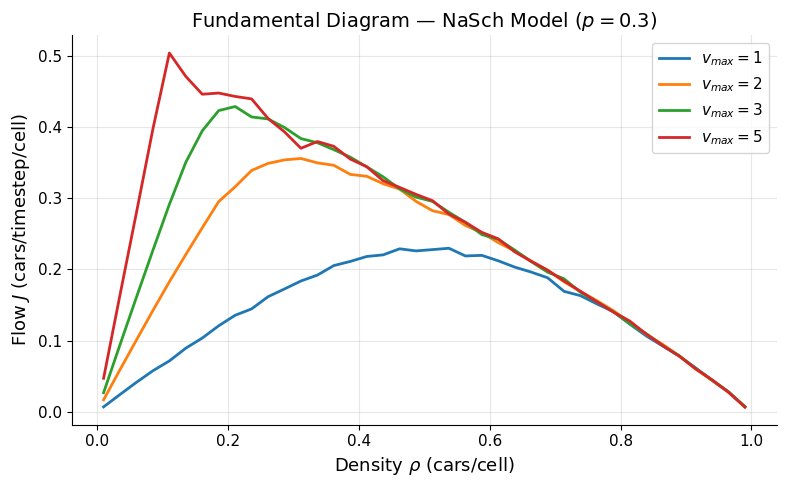

Fundamental diagrams computed. Each curve shows the classic hump shape:
free-flow on the left, capacity at the peak, and congestion on the right.


In [19]:
class TrafficCA_Periodic:
    """NaSch CA with periodic (closed) boundary — for fundamental diagram."""

    def __init__(self, L=500, n_cars=100, v_max=5, p_rand=0.3):
        self.L      = L
        self.v_max  = v_max
        self.p_rand = p_rand
        self.road   = np.full(L, -1, dtype=int)
        # Place cars randomly
        positions = np.random.choice(L, n_cars, replace=False)
        self.road[positions] = np.random.randint(0, v_max + 1, n_cars)

    def step(self):
        road   = self.road
        L      = self.L
        v_max  = self.v_max
        p_rand = self.p_rand

        car_pos = np.where(road >= 0)[0]
        if len(car_pos) == 0:
            return

        velocities = road[car_pos].copy()

        # Rule 1: Acceleration
        velocities = np.minimum(velocities + 1, v_max)

        # Rule 2: Braking — periodic gap
        gaps = np.empty(len(car_pos), dtype=int)
        for i, p in enumerate(car_pos):
            g = 0
            for j in range(1, L):
                if road[(p + j) % L] >= 0:
                    break
                g += 1
            gaps[i] = g
        velocities = np.minimum(velocities, gaps)
        velocities = np.maximum(velocities, 0)

        # Rule 3: Randomisation
        rand_mask = np.random.random(len(car_pos)) < p_rand
        velocities[rand_mask] = np.maximum(velocities[rand_mask] - 1, 0)

        # Rule 4: Movement (periodic wrap)
        new_road = np.full(L, -1, dtype=int)
        new_pos  = (car_pos + velocities) % L
        new_road[new_pos] = velocities
        self.road = new_road

    def mean_flow(self):
        car_pos = np.where(self.road >= 0)[0]
        if len(car_pos) == 0:
            return 0.0
        return float(np.mean(self.road[car_pos])) * len(car_pos) / self.L


def fundamental_diagram(v_max=5, L=200, p_rand=0.3, n_densities=40,
                         T_warmup=300, T_measure=500):
    """Compute J vs rho for the periodic NaSch model."""
    densities = np.linspace(0.01, 0.99, n_densities)
    flows     = np.zeros(n_densities)
    for k, rho in enumerate(densities):
        n_cars = max(1, int(rho * L))
        sim = TrafficCA_Periodic(L=L, n_cars=n_cars, v_max=v_max, p_rand=p_rand)
        for _ in range(T_warmup):
            sim.step()
        J = 0.0
        for _ in range(T_measure):
            sim.step()
            J += sim.mean_flow()
        flows[k] = J / T_measure
    return densities, flows


# ── Plot fundamental diagrams for several v_max values ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for vmax in [1, 2, 3, 5]:
    rho, J = fundamental_diagram(v_max=vmax, L=200, p_rand=0.3)
    ax.plot(rho, J, label=f'$v_{{max}}={vmax}$', linewidth=2)

ax.set_xlabel('Density $\\rho$ (cars/cell)', fontsize=13)
ax.set_ylabel('Flow $J$ (cars/timestep/cell)', fontsize=13)
ax.set_title('Fundamental Diagram — NaSch Model ($p=0.3$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Fundamental diagrams computed. Each curve shows the classic hump shape:")
print("free-flow on the left, capacity at the peak, and congestion on the right.")

## 5. Open Boundary Analysis — Through-Flow vs Inflow Rate

With open boundaries, the inflow probability $p_\text{in}$ controls how many cars try to enter. We measure the steady-state **through-flow** (cars exiting per timestep) as $p_\text{in}$ varies from 0 to 1.

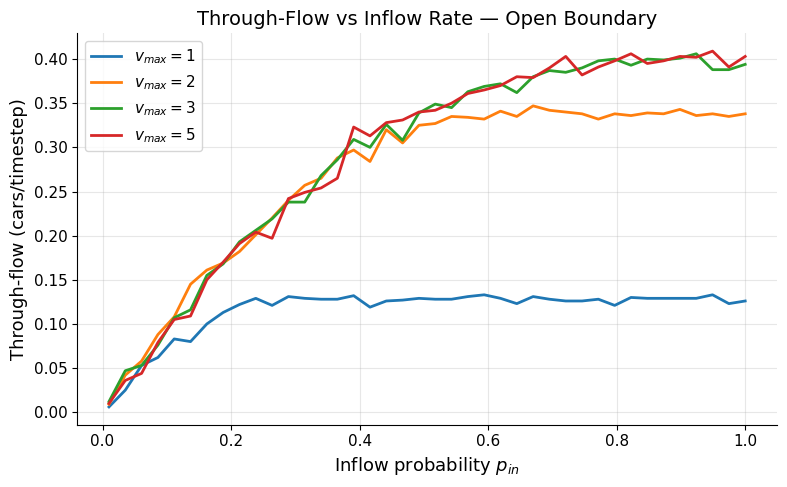

Through-flow saturates once the road reaches capacity.
Higher v_max → higher saturation flow (road capacity).


In [20]:
def sweep_inflow(v_max=5, L=L, p_rand=P_RAND,
                 p_in_values=None, T_warmup=T_WARMUP, T_measure=T_MEASURE):
    """Measure through-flow for a range of inflow probabilities."""
    if p_in_values is None:
        p_in_values = np.linspace(0.01, 1.0, 40)
    flows = np.zeros(len(p_in_values))
    for k, p_in in enumerate(p_in_values):
        sim = TrafficCA(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
        sim.warmup(T_warmup)
        flows[k] = sim.run(T_measure)
    return p_in_values, flows


p_vals = np.linspace(0.01, 1.0, 40)

fig, ax = plt.subplots(figsize=(8, 5))
for vmax in [1, 2, 3, 5]:
    p_in, flow = sweep_inflow(v_max=vmax, p_in_values=p_vals)
    ax.plot(p_in, flow, label=f'$v_{{max}}={vmax}$', linewidth=2)

ax.set_xlabel('Inflow probability $p_{{in}}$', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title('Through-Flow vs Inflow Rate — Open Boundary', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Through-flow saturates once the road reaches capacity.")
print("Higher v_max → higher saturation flow (road capacity).")

## 6. Space-Time Diagrams

Space-time diagrams show car positions (x-axis) at each timestep (y-axis). They reveal:
- **Free flow**: diagonal tracks (cars moving steadily)
- **Stop-and-go waves**: backward-propagating density waves (characteristic of congestion)
- **Traffic light effects**: queues forming and clearing at light positions

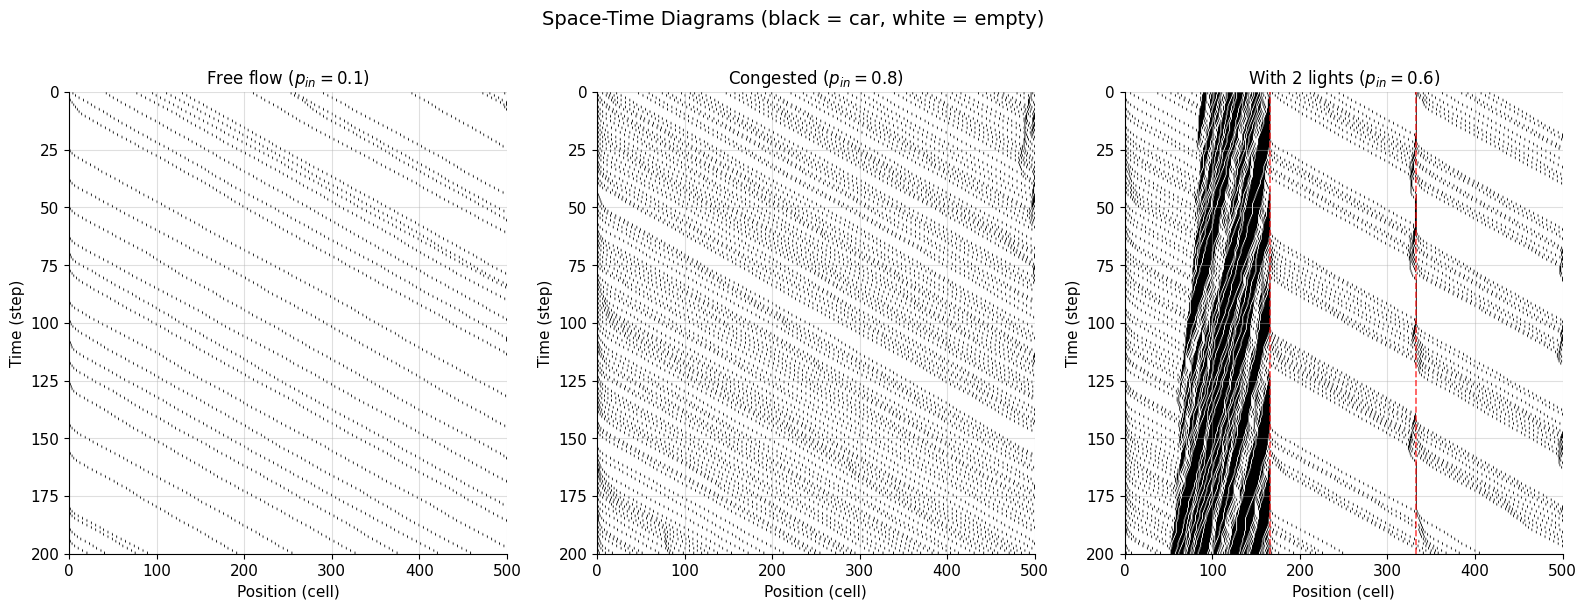

Left: sparse diagonal tracks = free flow.
Middle: backward-tilted bands = stop-and-go waves.
Right: queues form and clear at red dashed light positions.


In [21]:
def record_spacetime(sim, T_warmup=300, T_record=200):
    """Run sim and record occupancy grid of shape (T_record, L)."""
    for _ in range(T_warmup):
        sim.step()
    grid = np.zeros((T_record, sim.L), dtype=int)
    for t in range(T_record):
        grid[t] = sim.get_snapshot()
        sim.step()
    return grid


fig, axes = plt.subplots(1, 3, figsize=(16, 6))
scenarios = [
    ("Free flow ($p_{in}=0.1$)",      TrafficCA(L=L, v_max=5, p_rand=P_RAND, p_in=0.1)),
    ("Congested ($p_{in}=0.8$)",       TrafficCA(L=L, v_max=5, p_rand=P_RAND, p_in=0.8)),
    ("With 2 lights ($p_{in}=0.6$)",   TrafficCAWithLights(L=L, v_max=5, p_rand=P_RAND,
                                                           p_in=0.6, N=2, T_cycle=40, T_green=20)),
]

for ax, (title, sim) in zip(axes, scenarios):
    grid = record_spacetime(sim, T_warmup=300, T_record=200)
    ax.imshow(grid, aspect='auto', cmap='binary', origin='upper',
              extent=[0, L, 200, 0])

    # Mark light positions if applicable
    if hasattr(sim, 'light_pos'):
        for lp in sim.light_pos:
            ax.axvline(lp, color='red', linewidth=1.2, alpha=0.7, linestyle='--')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Position (cell)', fontsize=11)
    ax.set_ylabel('Time (step)', fontsize=11)

plt.suptitle('Space-Time Diagrams (black = car, white = empty)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Left: sparse diagonal tracks = free flow.")
print("Middle: backward-tilted bands = stop-and-go waves.")
print("Right: queues form and clear at red dashed light positions.")